In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
import pandas as pd

df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [9]:
df = df.iloc[:, :2]

In [11]:
df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (5572, 2)

Missing values:
label      0
message    0
dtype: int64

Duplicate rows:
403


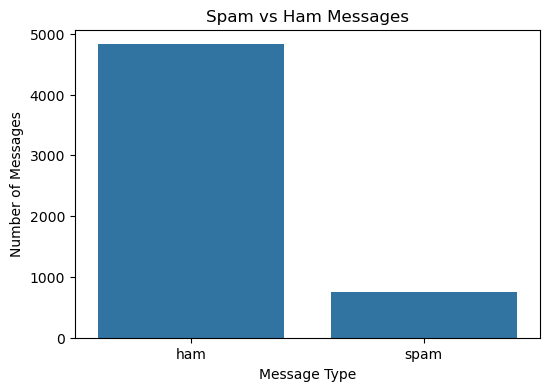

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [14]:
df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [15]:
df[["label", "label_encoded"]].head()

,label,label_encoded
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [16]:
df["message_length"] = df["message"].apply(len)

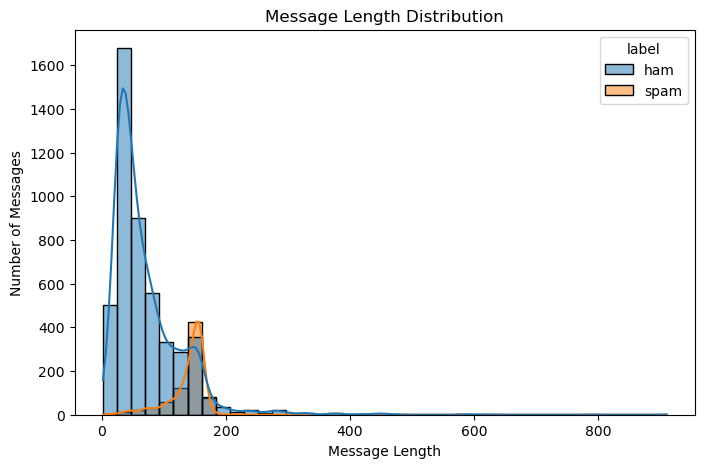

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Number of Messages")

plt.show()

In [18]:
X = df["message"]
y = df["label_encoded"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

In [21]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [22]:
X_test_tfidf = tfidf.transform(X_test)


In [23]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4457, 5000)
Testing shape: (1115, 5000)


In [24]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [25]:
y_pred = svm_model.predict(X_test_tfidf)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Support Vector Machine Results")
print("--------------------------------")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Support Vector Machine Results
--------------------------------
Accuracy : 0.9829596412556054
Precision: 0.9850746268656716
Recall   : 0.8859060402684564
F1 Score : 0.9328621908127208


In [27]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



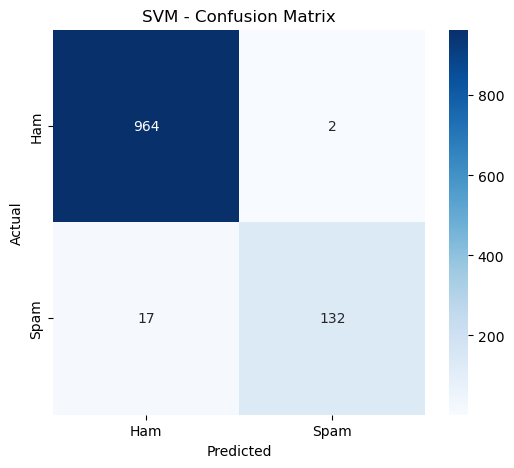

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
new_messages = [
    "Congratulations! You have won a free prize. Call now to claim your reward!",
    "Hey, are we still meeting tomorrow?",
    "URGENT! You have won £1000. Text WIN to 87121 now!",
    "Can you send me the notes from today's class?"
]
new_messages_tfidf = tfidf.transform(new_messages)
predictions = svm_model.predict(new_messages_tfidf)

In [31]:
for message, prediction in zip(new_messages, predictions):

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    print("Message:", message)
    print("Prediction:", result)
    print("-" * 70)

Message: Congratulations! You have won a free prize. Call now to claim your reward!
Prediction: SPAM
----------------------------------------------------------------------
Message: Hey, are we still meeting tomorrow?
Prediction: HAM
----------------------------------------------------------------------
Message: URGENT! You have won £1000. Text WIN to 87121 now!
Prediction: SPAM
----------------------------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: HAM
----------------------------------------------------------------------


In [32]:
import joblib

joblib.dump(
    svm_model,
    "spam_svm_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']